In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# # Install Surprise library (this will re-install scikit-surprise with the compatible numpy)
# !pip install surprise

# # Surprise library for recommendation models
# from surprise import Dataset, Reader, SVD, accuracy
# from surprise.model_selection import train_test_split as surprise_train_test_split

# Scikit-learn metrics and utilities
from sklearn.metrics import mean_squared_error, precision_score, recall_score
from sklearn.model_selection import train_test_split as _train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [3]:
# loading data
data1=pd.read_csv('anime_dataset.csv')
data2=pd.read_csv('manga_dataset.csv')

df=data1.merge(data2,on="mal_id",how="inner")
df.head()


,mal_id,title_x,title_english_x,title_japanese_x,type_x,source,episodes,status_x,airing,aired_from,...,popularity_y,members_y,favorites_y,authors,serializations,genres_y,themes_y,demographics_y,synopsis_y,image_url_y
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,27,288956,23729,"Urasawa, Naoki",Big Comic Original,Award Winning|Drama|Mystery,Adult Cast|Psychological,Seinen,"Kenzou Tenma, a renowned Japanese neurosurgeon...",https://myanimelist.net/images/manga/3/258224.jpg
1,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,160,102198,7654,"Morikawa, George",Shounen Magazine (Weekly),Award Winning|Sports,Combat Sports,Shounen,Makunouchi Ippo is a 16-year-old high school s...,https://myanimelist.net/images/manga/2/250313.jpg
2,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,502,41150,1951,"Tanemura, Arina",Ribon Magazine,Comedy|Drama|Fantasy|Romance|Supernatural,Music|Showbiz,Shoujo,"At the tender age of 12, Mitsuki Kouyama has a...",https://myanimelist.net/images/manga/3/175970.jpg
3,15,Eyeshield 21,NaN,アイシールド21,TV,Manga,145.0,Finished Airing,False,2005-04-06,...,229,77872,5041,"Akamatsu, Ken",Shounen Magazine (Weekly),Action|Adventure|Comedy|Fantasy|Romance|Supern...,Harem|Martial Arts|School,Shounen,"Negi Springfield, a 10-year-old wizard who rec...",https://myanimelist.net/images/manga/1/259286.jpg
4,16,Hachimitsu to Clover,Honey and Clover,ハチミツとクローバー,TV,Manga,24.0,Finished Airing,False,2005-04-15,...,258,71264,3921,"Akamatsu, Ken",Shounen Magazine (Weekly),Award Winning|Comedy|Romance|Ecchi,Harem,Shounen,It is said that if a couple gets into the Univ...,https://myanimelist.net/images/manga/1/259287.jpg


In [4]:
# data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11686 entries, 0 to 11685
Data columns (total 52 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mal_id            11686 non-null  int64  
 1   title_x           11686 non-null  object 
 2   title_english_x   5633 non-null   object 
 3   title_japanese_x  11642 non-null  object 
 4   type_x            11665 non-null  object 
 5   source            11686 non-null  object 
 6   episodes          11408 non-null  float64
 7   status_x          11686 non-null  object 
 8   airing            11686 non-null  bool   
 9   aired_from        11460 non-null  object 
 10  aired_to          5254 non-null   object 
 11  duration          11686 non-null  object 
 12  rating            11470 non-null  object 
 13  score_x           8826 non-null   float64
 14  scored_by_x       8826 non-null   float64
 15  rank_x            9186 non-null   float64
 16  popularity_x      11686 non-null  int64 

In [5]:
# data description
df.describe()

,mal_id,episodes,score_x,scored_by_x,rank_x,popularity_x,members_x,favorites_x,year,chapters,volumes,score_y,scored_by_y,rank_y,popularity_y,members_y,favorites_y
count,11686.000000,11408.000000,8826.000000,8.826000e+03,9186.000000,11686.000000,1.168600e+04,11686.000000,3079.000000,9619.000000,10078.000000,6836.000000,6836.000000,7878.000000,11686.000000,11686.000000,11686.000000
mean,25853.577700,14.199684,6.503524,3.082467e+04,9772.338885,12852.300958,4.587920e+04,579.119117,2005.712244,24.805697,3.976384,6.963066,2490.857226,16547.943387,29244.332449,3599.738747,121.534400
std,21742.925566,52.442698,0.874144,1.256338e+05,6178.181191,8177.397995,1.850730e+05,5963.247571,13.761038,54.610230,6.341967,0.550303,9516.372316,9641.811553,19999.285216,15956.511917,1226.212033
min,1.000000,1.000000,1.890000,1.030000e+02,2.000000,1.000000,0.000000e+00,0.000000,1961.000000,1.000000,1.000000,4.600000,101.000000,2.000000,12.000000,24.000000,0.000000
25%,4000.750000,1.000000,5.910000,5.252500e+02,4548.250000,6103.500000,4.620000e+02,0.000000,1999.000000,5.000000,1.000000,6.610000,251.750000,7748.250000,12101.000000,166.000000,0.000000
50%,21691.000000,2.000000,6.530000,2.115000e+03,9013.000000,11625.000000,2.732500e+03,3.000000,2007.000000,9.000000,1.000000,6.920000,541.000000,17274.500000,26276.000000,535.000000,1.000000
75%,45819.500000,13.000000,7.140000,1.165375e+04,14477.500000,18985.750000,1.536475e+04,32.000000,2015.000000,21.000000,4.000000,7.280000,1451.000000,25620.000000,44475.750000,1751.000000,7.000000
max,64001.000000,3000.000000,9.150000,3.060289e+06,22548.000000,29935.000000,4.348557e+06,251194.000000,2027.000000,1957.000000,200.000000,9.340000,244081.000000,30168.000000,78630.000000,457036.000000,51533.000000


In [7]:
#duplicated columns
df.duplicated().sum()

np.int64(47)

In [8]:
#drop duplicates columns
df.drop_duplicates(inplace=True)


In [9]:
## looking for null rows
df.isnull().sum()*100/len(df)

,0
mal_id,0.000000
title_x,0.000000
type_x,0.154652
source,0.000000
episodes,2.122175
status_x,0.000000
airing,0.000000
aired_from,1.855830
duration,0.000000
rating,1.692585


In [6]:
# droping null values  > 40%
cols_to_drop = [
    'title_english_x', 'title_english_y', 'title_japanese_x', 'title_japanese_y',
    'season', 'year', 'licensors', 'demographics_x', 'demographics_y',
    'themes_y', 'aired_to', 'published_to', 'producers', 'serializations'
]
df = df.drop(columns=cols_to_drop)


In [ ]:
## filling null values
df['score_x'] = df['score_x'].fillna(df['score_x'].mean())
df['scored_by_x'] = df['scored_by_x'].fillna(df['scored_by_x'].mean())
df['members_x'] = df['members_x'].fillna(df['members_x'].mean())
df['favorites_x'] = df['favorites_x'].fillna(df['favorites_x'].mean())
df['rank_x'] = df['rank_x'].fillna(df['rank_x'].mean())
df['popularity_x'] = df['popularity_x'].fillna(df['popularity_x'].mean())
df['episodes'] = df['episodes'].fillna(df['episodes'].mean())
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['genres_x'] = df['genres_x'].fillna(df['genres_x'].mode()[0])
df['studios'] = df['studios'].fillna(df['studios'].mode()[0])
df['source'] = df['source'].fillna(df['source'].mode()[0])
df['type_x'] = df['type_x'].    fillna(df['type_x'].mode()[0])
df['status_x'] = df['status_x'].fillna(df['status_x'].mode()[0])
df['aired_from'] = df['aired_from'].fillna(df['aired_from'].mode()[0])
df['published_from'] = df['published_from'].fillna(df['published_from'].mode()[0])
# Fill missing text columns
text_cols = [
    'genres_x',
    'themes_x',
    'synopsis_x',
    'studios',
    'authors'
]

for col in text_cols:
    df[col] = df[col].fillna('Unknown')

# Fill missing scores
df['score_x'] = df['score_x'].fillna(df['score_x'].mean())

In [10]:
df.columns

Index(['mal_id', 'title_x', 'type_x', 'source', 'episodes', 'status_x',
       'airing', 'aired_from', 'duration', 'rating', 'score_x', 'scored_by_x',
       'rank_x', 'popularity_x', 'members_x', 'favorites_x', 'studios',
       'genres_x', 'themes_x', 'synopsis_x', 'image_url_x', 'title_y',
       'type_y', 'chapters', 'volumes', 'status_y', 'publishing',
       'published_from', 'score_y', 'scored_by_y', 'rank_y', 'popularity_y',
       'members_y', 'favorites_y', 'authors', 'genres_y', 'synopsis_y',
       'image_url_y'],
      dtype='object')

# visualization

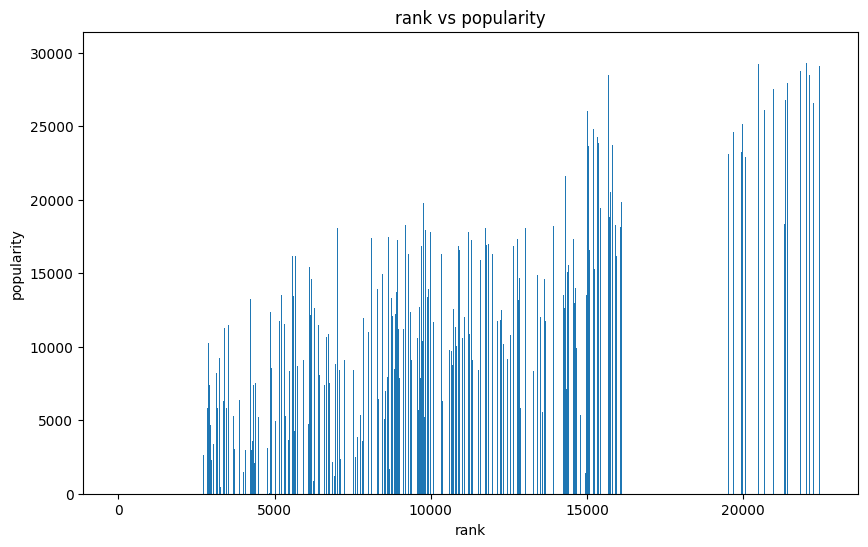

In [11]:
plt.figure(figsize=(10,6))
plt.bar(df["rank_x"],df["popularity_x"])
plt.xlabel("rank")
plt.ylabel("popularity")
plt.title("rank vs popularity")
plt.show()

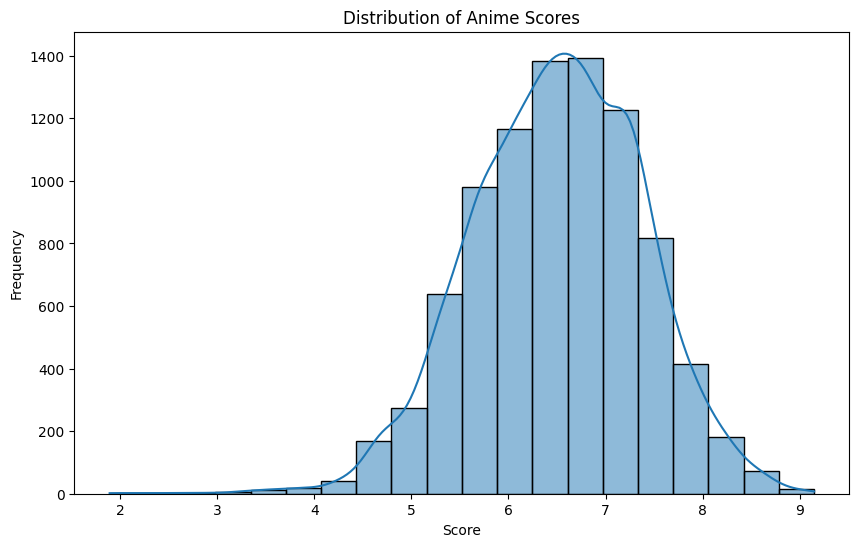

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['score_x'], bins=20, kde=True)
plt.title('Distribution of Anime Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

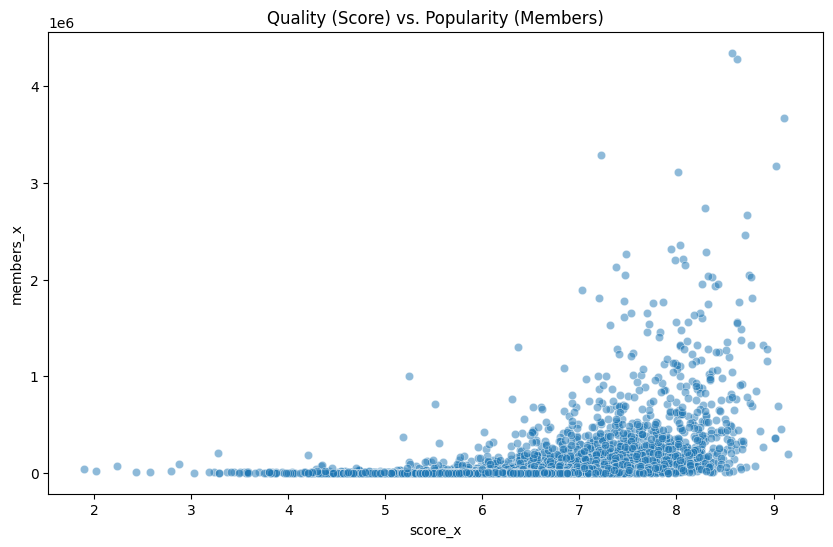

In [15]:
 # Anime Score vs. Members (Popularity)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='score_x', y='members_x', alpha=0.5)
plt.title('Quality (Score) vs. Popularity (Members)')
plt.show()

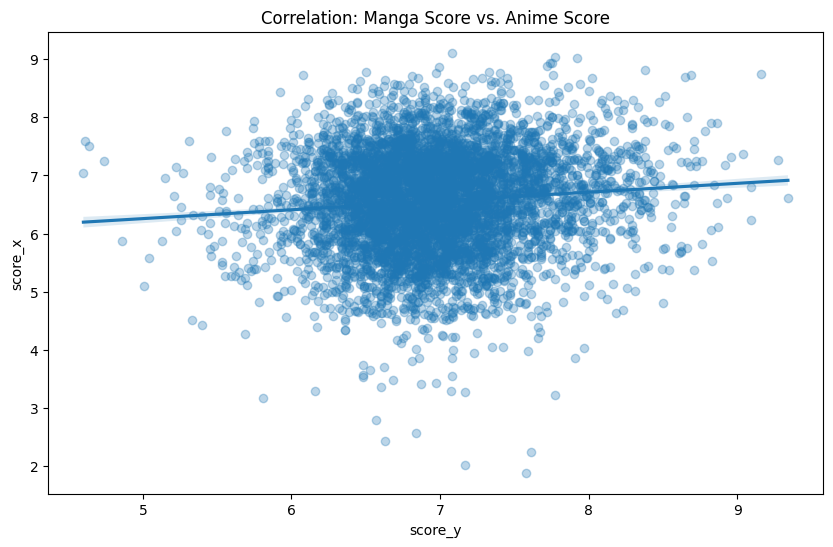

In [14]:
#  Anime vs. Manga Scores
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='score_y', y='score_x', scatter_kws={'alpha':0.3})
plt.title('Correlation: Manga Score vs. Anime Score')
plt.show()


In [13]:
# save cleaned data
df.to_csv('tableau.csv', index=False)

# MODELING

## TD-IDF +COSINE SIMILARITY

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine synopsis_x and synopsis_y or choose one. Let's start with synopsis_x.
df_content = df.copy()
df_content['content'] = df_content['synopsis_x'].fillna('') + ' ' + df_content['genres_x'].fillna('') + ' ' + df_content['themes_x'].fillna('')

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the content column to get the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df_content['content'])

# Calculate cosine similarity matrix
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Cosine similarity matrix shape:", cosine_sim_matrix.shape)

TF-IDF matrix shape: (11639, 37812)
Cosine similarity matrix shape: (11639, 11639)


In [24]:
# Create a mapping from mal_id to index and vice versa for easy lookup
mal_id_to_index = pd.Series(df_content.index, index=df_content['mal_id']).drop_duplicates()
index_to_mal_id = pd.Series(df_content['mal_id'], index=df_content.index).drop_duplicates()

def get_content_based_recommendations(mal_id, cosine_sim_matrix, df_content, mal_id_to_index, index_to_mal_id, top_n=10):
    # Get the index of the anime that matches the mal_id
    if mal_id not in mal_id_to_index:
        return "Anime not found."

    idx = mal_id_to_index[mal_id]

    # Get the pairwise similarity scores with all anime
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort the anime based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the top_n most similar anime (excluding itself)
    sim_scores = sim_scores[1:top_n+1]

    # Get the anime indices
    anime_indices = [i[0] for i in sim_scores]

    # Return the top N most similar anime titles and their similarity scores
    recommended_anime = df_content.iloc[anime_indices][['mal_id', 'title_x', 'score_x', 'genres_x']]
    recommended_anime['similarity_score'] = [i[1] for i in sim_scores]
    return recommended_anime

# Example usage:
anime_id_to_recommend = df_content['mal_id'].iloc[0] # Using the first anime in the dataframe as an example
print(f"Recommendations for Anime with mal_id {anime_id_to_recommend} ({df_content[df_content['mal_id'] == anime_id_to_recommend]['title_x'].iloc[0]}):")
recommendations = get_content_based_recommendations(anime_id_to_recommend, cosine_sim_matrix, df_content, mal_id_to_index, index_to_mal_id)
display(recommendations)

Recommendations for Anime with mal_id 1 (Cowboy Bebop):


,mal_id,title_x,score_x,genres_x,similarity_score
5325,17205,Cowboy Bebop: Ein no Natsuyasumi,6.34,Comedy,0.126833
1356,1660,Kurogane Communication,6.86,Action|Adventure|Drama|Sci-Fi,0.111973
11222,61939,MARO17: Do Atama Kara Kimeyouze,6.55,Action,0.108962
10782,59713,Planetarium Doraemon: Uchuu no Mokei,NaN,Action|Sci-Fi,0.103040
5263,16696,2020 Nyeon Ujuui Wonder Kiddy,5.58,Sci-Fi,0.099342
9832,54089,Hoshizora wo Miagete: 365 Hi no Hoshi Nikki,NaN,Sci-Fi,0.099342
10192,56315,Fei Xiang Yueqiu,NaN,Sci-Fi,0.099342
10635,58907,Dubu Xinghai,NaN,Sci-Fi,0.099342
10339,57065,Mei Shaonu Da Picha 3rd Season,NaN,Comedy,0.099059
2417,3067,Saraba Uchuu Senkan Yamato: Ai no Senshi-tachi,7.23,Action|Drama|Sci-Fi,0.094815


### Top-Rated Anime

In [28]:
# Sort the DataFrame by 'score_x' in descending order to get top-rated anime
top_rated_anime = df.sort_values(by='score_x', ascending=False)

# Display the top 10 rated anime
print("Top 10 Rated Anime:")
display(top_rated_anime[['title_x', 'score_x', 'genres_x', 'synopsis_x']].head(10))

Top 10 Rated Anime:


,title_x,score_x,genres_x,synopsis_x
11132,Steel Ball Run: JoJo no Kimyou na Bouken,9.15,Action|Adventure|Mystery|Supernatural,"In the American Old West, the world's greatest..."
3278,Fullmetal Alchemist: Brotherhood,9.11,Action|Adventure|Drama|Fantasy,After a horrific alchemy experiment goes wrong...
10421,Chainsaw Man Movie: Reze-hen,9.08,Action|Fantasy,Despite the immediate challenges following bec...
6555,Gintama°,9.05,Action|Comedy|Sci-Fi,"Gintoki, Shinpachi, and Kagura return as the f..."
4673,Hunter x Hunter (2011),9.03,Action|Adventure|Fantasy,Hunters devote themselves to accomplishing haz...
694,Ginga Eiyuu Densetsu,9.02,Drama|Sci-Fi,The 150-year-long stalemate between the two in...
5142,Gintama': Enchousen,9.02,Action|Comedy|Sci-Fi,"While Gintoki Sakata was away, the Yorozuya fo..."
2997,Clannad: After Story,8.93,Drama|Romance,Tomoya Okazaki and Nagisa Furukawa have gradua...
776,Gintama,8.93,Action|Comedy|Sci-Fi,Edo is a city that was home to the vigor and a...
7,Monster,8.89,Drama|Mystery|Suspense,"Dr. Kenzou Tenma, an elite neurosurgeon recent..."


/tmp/ipykernel_5233/398513980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score_x', y='title_x', data=top_rated_anime.head(10), palette='viridis')


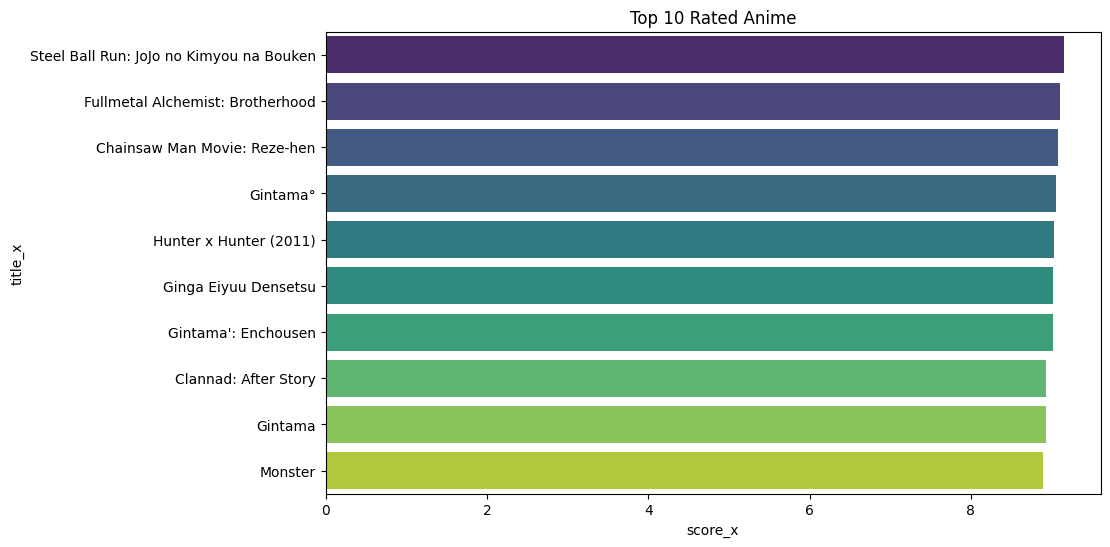

In [29]:
# top 10 movies
plt.figure(figsize=(10, 6))
sns.barplot(x='score_x', y='title_x', data=top_rated_anime.head(10), palette='viridis')
plt.title('Top 10 Rated Anime')
plt.show()